 # EfficientNet-B0 Fine-Tuning – ISIC 2018 MEL vs NV

 Binary classification: **MEL** (melanoma) vs **NV** (melanocytic nevi) using the ISIC 2018 Task 3 training set.

 | Detail | Value |
 |---|---|
 | Backbone | EfficientNet-B0 (ImageNet-pretrained) |
 | Frozen layers | Stem + MBConv blocks 1–5 (features[0..5]); only blocks 6–8 + classifier head are trained |
 | Input size | 224 × 224 (EfficientNet-B0 default) |
 | Train/Val split | 80 / 20, `random_split` seeded at 42 |
 | Class imbalance | `WeightedRandomSampler` on train split (NV greatly outnumbers MEL) |
 | Val metric | ROC-AUC |
 | Checkpointing | Per-epoch, auto-resume from latest `epoch_*.pth` |

 **Freeze rationale:** EfficientNet-B0's first six feature blocks (stem conv + MBConv blocks 1–5) learn very general ImageNet features (edges, textures, simple patterns) that transfer well to dermoscopy.  The final MBConv blocks (6–8) and the classifier head are left trainable so the network can adapt its high-level representations to the MEL/NV task without over-fitting.

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import sys
import glob
import math

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from datasets import ISIC2018Dataset, TransformDataset

print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

PyTorch 2.6.0+cu124 | CUDA available: False


In [ ]:
# ── Parameters (edit here) ────────────────────────────────────────────────────
DATASET_DIR    = "../dataset/ISIC_2018/ISIC2018_Task3_Training_Input"
LABELS_CSV     = "../dataset/ISIC_2018/ISIC2018_Task3_Training_GroundTruth.csv"
IMAGE_SIZE     = 224          # EfficientNet-B0 default
BATCH_SIZE     = 8
NUM_WORKERS    = 1
VAL_SPLIT      = 0.2          # fraction held out for validation
LEARNING_RATE  = 1e-4         # lower LR appropriate for fine-tuning
NUM_EPOCHS     = 20
LABEL_SMOOTHING= 0.3          # aggressive label smoothing
CHECKPOINT_DIR = "../checkpoints/efficientnet_nv_mel_classifier/run_2"
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
LABEL_NAMES    = ["NV", "MEL"]

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Using device  : {DEVICE}")
print(f"Image size    : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Checkpoint dir: {os.path.abspath(CHECKPOINT_DIR)}")

Using device  : cpu
Image size    : 224 x 224
Checkpoint dir: /home/tejas/dev/capstone/checkpoints/efficientnet_nv_mel_classifier/run_2


In [ ]:
# ── Transforms ───────────────────────────────────────────────────────────────
# Train: augmentations to reduce over-fitting on the small MEL class.
# Val  : deterministic centre-crop only.
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                         [0.229, 0.224, 0.225]),   # ImageNet std
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print("Transform pipelines defined.")

Transform pipelines defined.


In [ ]:
# ── Dataset & DataLoaders ─────────────────────────────────────────────────────
# Base dataset with transform=None so it returns raw PIL images.
# TransformDataset wraps each split with its own augmentation pipeline.

full_dataset = ISIC2018Dataset(
    root_dir       = DATASET_DIR,
    transform      = None,
    labels_csv     = LABELS_CSV,
    include_labels = LABEL_NAMES,
)

print(f"Total labeled samples (NV+MEL): {len(full_dataset)}")

# ── Train / Val split ─────────────────────────────────────────────────────────
n_total = len(full_dataset)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(42)
train_sub, val_sub = random_split(
    full_dataset, [n_train, n_val], generator=generator
)

train_dataset = TransformDataset(train_sub, train_transform)
val_dataset   = TransformDataset(val_sub,   val_transform)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val   samples : {len(val_dataset):,}")

# ── Collect raw one-hot labels for WeightedRandomSampler (no image I/O) ──────
# label_map rows are [NV, MEL]; binary label = argmax
all_labels = [
    int(full_dataset.label_map.loc[
        os.path.splitext(os.path.basename(p))[0]
    ].values.argmax())
    for p in full_dataset.image_paths
]
class_counts = np.bincount(all_labels)
print(f"Class counts  : NV={class_counts[0]:,}  MEL={class_counts[1]:,}")

# ── WeightedRandomSampler on train split only ─────────────────────────────────
train_labels   = [all_labels[i] for i in train_sub.indices]
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[lbl] for lbl in train_labels]
train_sampler  = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(train_dataset),
    replacement = True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = train_sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE == "cuda",
)

print(f"Train batches/epoch : {len(train_loader)}")
print(f"Val   batches/epoch : {len(val_loader)}")

Found 10015 valid JPEG images in '../dataset/ISIC_2018/ISIC2018_Task3_Training_Input'
Total labeled samples (NV+MEL): 10015
Train samples : 8,012
Val   samples : 2,003
Class counts  : NV=8,902  MEL=1,113
Train batches/epoch : 1002
Val   batches/epoch : 251


Batch shape : torch.Size([8, 3, 224, 224])
Labels (raw): [[0.0, 1.0], [0.0, 1.0], [0.0, 1.0], [1.0, 0.0], [0.0, 1.0], [0.0, 1.0], [0.0, 1.0], [0.0, 1.0]]


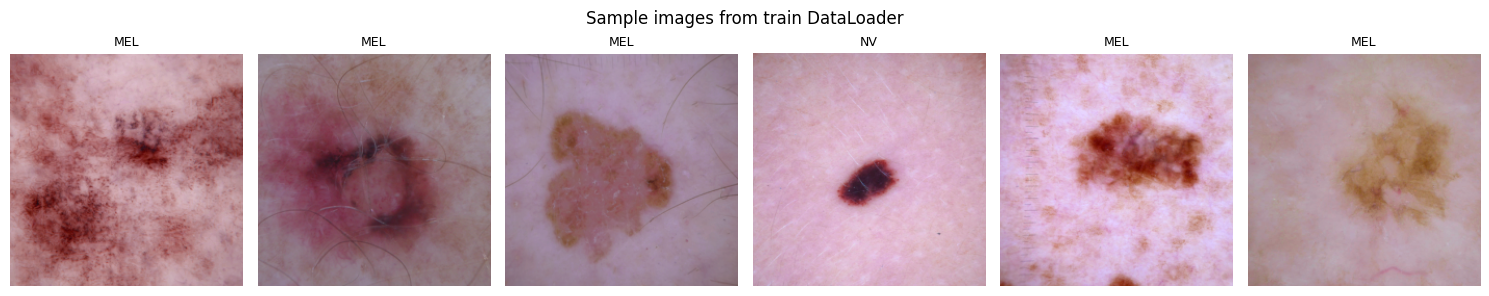

In [ ]:
# ── Sanity check: visualise a batch ──────────────────────────────────────────
sample_imgs, sample_labels = next(iter(train_loader))
print("Batch shape :", sample_imgs.shape)
print("Labels (raw):", sample_labels[:8].tolist())

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
for i, ax in enumerate(axes):
    img = sample_imgs[i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    cls = sample_labels[i].argmax().item()
    ax.imshow(img)
    ax.set_title(LABEL_NAMES[cls], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample images from train DataLoader", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Model – EfficientNet-B0 with partial freezing ────────────────────────────
#
# EfficientNet-B0 feature extractor layout (model.features):
#   [0]  Conv2dNormActivation  – stem (32 filters)
#   [1]  Sequential            – MBConv block stage 1
#   [2]  Sequential            – MBConv block stage 2
#   [3]  Sequential            – MBConv block stage 3
#   [4]  Sequential            – MBConv block stage 4
#   [5]  Sequential            – MBConv block stage 5
#   [6]  Sequential            – MBConv block stage 6  ← trainable
#   [7]  Sequential            – MBConv block stage 7  ← trainable
#   [8]  Conv2dNormActivation  – head conv              ← trainable
#
# Freeze: features[0..5] (stem + early MBConv stages).
# These parameters capture generic low/mid-level features (edges, colour
# gradients, textures) from ImageNet that transfer well to dermoscopy.
# The last three stages and the classifier head are left trainable to allow
# the network to learn task-specific high-level representations.

backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze stem + MBConv stages 1–5
FREEZE_UP_TO = 6   # features[0..5] frozen; features[6..8] trainable
for i in range(FREEZE_UP_TO):
    for param in backbone.features[i].parameters():
        param.requires_grad = False

# Replace the classifier head: 1280-d → 1 (NV/MEL)
in_features = backbone.classifier[1].in_features
backbone.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_features, 1),
)

model = backbone.to(DEVICE)

frozen   = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Frozen parameters   : {frozen:,}")
print(f"Trainable parameters: {trainable:,}")

Frozen parameters   : 851,808
Trainable parameters: 3,157,021


In [ ]:
# ── Loss / optimiser / scheduler + auto-resume ────────────────────────────────
criterion = nn.BCEWithLogitsLoss()
# Only pass parameters that require gradients to the optimiser
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

# ── History buffers ───────────────────────────────────────────────────────────
train_losses     = []
val_losses       = []
val_aucs         = []
val_conf_matrices= []
val_accuracies   = []
val_precisions   = []
val_recalls      = []
val_f1s          = []
start_epoch      = 1

# ── Resume from latest checkpoint if one exists ───────────────────────────────
existing = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pth")))
if existing:
    latest = existing[-1]
    ckpt   = torch.load(latest, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optim_state"])
    scheduler.load_state_dict(ckpt["sched_state"])
    start_epoch      = ckpt["epoch"] + 1
    train_losses     = ckpt.get("train_losses", [])
    val_losses       = ckpt.get("val_losses", [])
    val_aucs         = ckpt.get("val_aucs", [])
    val_conf_matrices= ckpt.get("val_conf_matrices", [])
    val_accuracies   = ckpt.get("val_accuracies", [])
    val_precisions   = ckpt.get("val_precisions", [])
    val_recalls      = ckpt.get("val_recalls", [])
    val_f1s          = ckpt.get("val_f1s", [])
    print(f"Resumed from '{latest}' (epoch {ckpt['epoch']} of {NUM_EPOCHS})")
else:
    print("No checkpoint found – starting from scratch.")

if start_epoch > NUM_EPOCHS:
    print(f"Training already complete ({NUM_EPOCHS} epochs done). Nothing to do.")

No checkpoint found – starting from scratch.


In [ ]:
# ── Training loop (checkpoints every epoch) ───────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    total        = 0

    pbar = tqdm(train_loader, desc=f"Epoch [{epoch:>3}/{NUM_EPOCHS}] train", leave=False)
    for imgs, labels_onehot in pbar:
        imgs          = imgs.to(DEVICE, non_blocking=True)
        labels_onehot = labels_onehot.to(DEVICE, non_blocking=True)
        labels        = labels_onehot.argmax(dim=1).float()

        # Apply aggressive label smoothing
        smoothed_labels = labels * (1.0 - LABEL_SMOOTHING) + 0.5 * LABEL_SMOOTHING

        logits = model(imgs).squeeze(-1)
        loss   = criterion(logits, smoothed_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        total        += imgs.size(0)
        pbar.set_postfix(loss=f"{running_loss / total:.4f}")

    scheduler.step()

    train_loss = running_loss / total
    train_losses.append(train_loss)

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    val_running_loss = 0.0
    val_total        = 0
    all_logits       = []
    all_targets      = []   # ground-truth class indices

    with torch.no_grad():
        for imgs, labels_onehot in tqdm(val_loader, desc=f"Epoch [{epoch:>3}/{NUM_EPOCHS}] val  ", leave=False):
            imgs          = imgs.to(DEVICE, non_blocking=True)
            labels_onehot = labels_onehot.to(DEVICE, non_blocking=True)
            labels        = labels_onehot.argmax(dim=1)

            logits = model(imgs).squeeze(-1)
            loss   = criterion(logits, labels.float())
            val_running_loss += loss.item() * imgs.size(0)
            val_total        += imgs.size(0)

            all_logits.extend(logits.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    val_loss = val_running_loss / val_total
    
    all_preds = (np.array(all_logits) > 0).astype(int)
    val_auc  = roc_auc_score(all_targets, all_logits)
    val_acc  = accuracy_score(all_targets, all_preds)
    val_prec = precision_score(all_targets, all_preds, zero_division=0)
    val_rec  = recall_score(all_targets, all_preds, zero_division=0)
    val_f1   = f1_score(all_targets, all_preds, zero_division=0)
    val_cm   = confusion_matrix(all_targets, all_preds)

    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    val_accuracies.append(val_acc)
    val_precisions.append(val_prec)
    val_recalls.append(val_rec)
    val_f1s.append(val_f1)
    val_conf_matrices.append(val_cm)

    print(
        f"Epoch [{epoch:>3}/{NUM_EPOCHS}]\n"
        f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}\n"
        f"  Val AUC: {val_auc:.4f} | Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | F1: {val_f1:.4f}\n"
        f"  Confusion Matrix:\n{val_cm}"
    )

    # ── Save per-epoch checkpoint ──────────────────────────────────────────────
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch:03d}.pth")
    torch.save({
        "epoch"       : epoch,
        "model_state" : model.state_dict(),
        "optim_state" : optimizer.state_dict(),
        "sched_state" : scheduler.state_dict(),
        "config": {
            "image_size"    : IMAGE_SIZE,
            "freeze_up_to"  : FREEZE_UP_TO,
            "num_classes"   : 2,
            "val_split"     : VAL_SPLIT,
            "label_smoothing": LABEL_SMOOTHING,
        },
        "train_losses"     : train_losses,
        "val_losses"       : val_losses,
        "val_aucs"         : val_aucs,
        "val_conf_matrices": val_conf_matrices,
        "val_accuracies"   : val_accuracies,
        "val_precisions"   : val_precisions,
        "val_recalls"      : val_recalls,
        "val_f1s"          : val_f1s,
    }, ckpt_path)
    print(f"  └─ Checkpoint saved: {ckpt_path}")

print("\nTraining complete.")

Epoch [  1/20]
  Train Loss: 0.6107 | Val Loss: 0.4222 | LR: 9.94e-05
  Val AUC: 0.9018 | Acc: 0.8183 | Prec: 0.3631 | Rec: 0.8097 | F1: 0.5014
  Confusion Matrix:
[[1456  321]
 [  43  183]]
  └─ Checkpoint saved: ../checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_001.pth


Epoch [  2/20]
  Train Loss: 0.5836 | Val Loss: 0.3609 | LR: 9.76e-05
  Val AUC: 0.9074 | Acc: 0.8692 | Prec: 0.4516 | Rec: 0.7434 | F1: 0.5619
  Confusion Matrix:
[[1573  204]
 [  58  168]]
  └─ Checkpoint saved: ../checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_002.pth


Epoch [  3/20]
  Train Loss: 0.5641 | Val Loss: 0.3420 | LR: 9.46e-05
  Val AUC: 0.9117 | Acc: 0.8792 | Prec: 0.4780 | Rec: 0.7699 | F1: 0.5898
  Confusion Matrix:
[[1587  190]
 [  52  174]]
  └─ Checkpoint saved: ../checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_003.pth


Epoch [  4/20]
  Train Loss: 0.5620 | Val Loss: 0.3386 | LR: 9.05e-05
  Val AUC: 0.8971 | Acc: 0.8917 | Prec: 0.5155 | Rec: 0.6637 | F1: 0.5803
  Confusion Matrix:
[[1636  141]
 [  76  150]]
  └─ Checkpoint saved: ../checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_004.pth


Epoch [  5/20]
  Train Loss: 0.5498 | Val Loss: 0.3097 | LR: 8.55e-05
  Val AUC: 0.9180 | Acc: 0.8942 | Prec: 0.5223 | Rec: 0.7257 | F1: 0.6074
  Confusion Matrix:
[[1627  150]
 [  62  164]]
  └─ Checkpoint saved: ../checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_005.pth


...

Epoch [ 16/20]
  Train Loss: 0.4972 | Val Loss: 0.2710 | LR: 1.05e-05
  Val AUC: 0.9167 | Acc: 0.9246 | Prec: 0.6728 | Rec: 0.6460 | F1: 0.6591
  Confusion Matrix:
[[1706   71]
 [  80  146]]
  └─ Checkpoint saved: ../checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_016.pth


Epoch [ 17/20]
  Train Loss: 0.4939 | Val Loss: 0.2563 | LR: 6.40e-06
  Val AUC: 0.9284 | Acc: 0.9256 | Prec: 0.6758 | Rec: 0.6549 | F1: 0.6652
  Confusion Matrix:
[[1706   71]
 [  78  148]]
  └─ Checkpoint saved: ../checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_017.pth


Epoch [ 18/20]
  Train Loss: 0.4941 | Val Loss: 0.2798 | LR: 3.42e-06
  Val AUC: 0.9302 | Acc: 0.9206 | Prec: 0.6345 | Rec: 0.6991 | F1: 0.6653
  Confusion Matrix:
[[1686   91]
 [  68  158]]
  └─ Checkpoint saved: ../checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_018.pth


Epoch [ 19/20]
  Train Loss: 0.4936 | Val Loss: 0.2648 | LR: 1.61e-06
  Val AUC: 0.9185 | Acc: 0.9251 | Prec: 0.6712 | Rec: 0.6593 | F1: 0.6652
  Confusion Matrix:
[[1704   73]
 [  77  149]]
  └─ Checkpoint saved: ../checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_019.pth


Epoch [ 20/20]
  Train Loss: 0.4918 | Val Loss: 0.2747 | LR: 1.00e-06
  Val AUC: 0.9120 | Acc: 0.9251 | Prec: 0.6776 | Rec: 0.6416 | F1: 0.6591
  Confusion Matrix:
[[1708   69]
 [  81  145]]
  └─ Checkpoint saved: ../checkpoints/efficientnet_nv_mel_classifier/run_2/epoch_020.pth

Training complete.


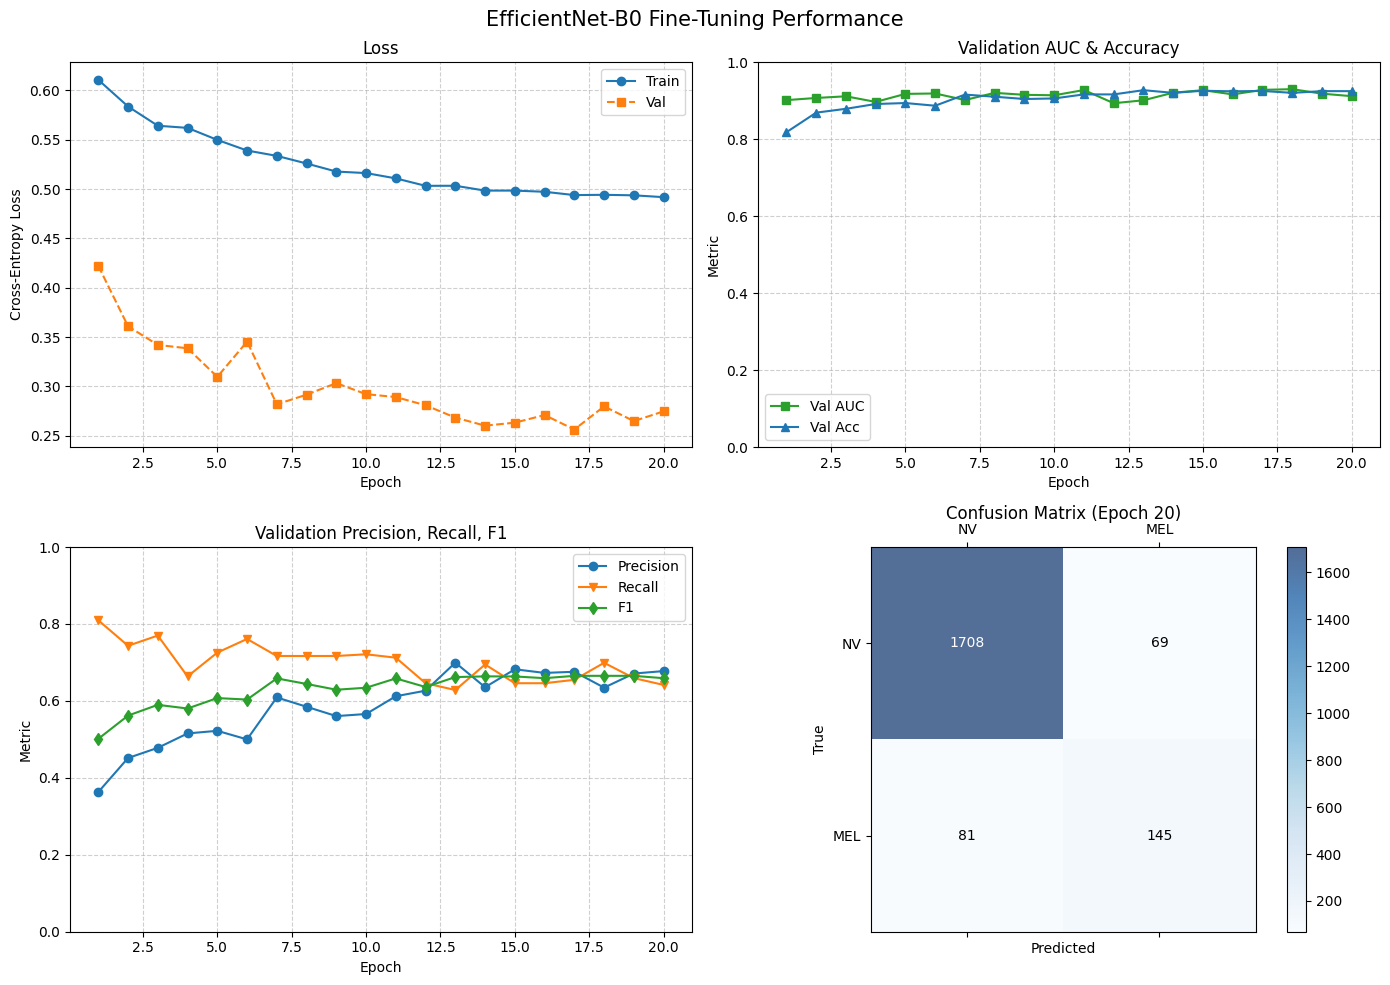

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
n_recorded = len(train_losses)
epochs_x   = range(1, n_recorded + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss
axes[0, 0].plot(epochs_x, train_losses, marker="o", linewidth=1.5, label="Train")
axes[0, 0].plot(epochs_x, val_losses,   marker="s", linewidth=1.5, label="Val", linestyle="--")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Cross-Entropy Loss")
axes[0, 0].set_title("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle="--", alpha=0.6)

# 2. AUC & Accuracy
axes[0, 1].plot(epochs_x, val_aucs, marker="s", linewidth=1.5, color="tab:green", label="Val AUC")
axes[0, 1].plot(epochs_x, val_accuracies, marker="^", linewidth=1.5, color="tab:blue", label="Val Acc")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Metric")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Validation AUC & Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle="--", alpha=0.6)

# 3. Precision, Recall, F1
axes[1, 0].plot(epochs_x, val_precisions, marker="o", linewidth=1.5, label="Precision")
axes[1, 0].plot(epochs_x, val_recalls, marker="v", linewidth=1.5, label="Recall")
axes[1, 0].plot(epochs_x, val_f1s, marker="d", linewidth=1.5, label="F1")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Metric")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_title("Validation Precision, Recall, F1")
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle="--", alpha=0.6)

# 4. Final Epoch Confusion Matrix
if n_recorded > 0:
    cm = val_conf_matrices[-1]
    cax = axes[1, 1].matshow(cm, cmap="Blues", alpha=0.7)
    fig.colorbar(cax, ax=axes[1, 1])
    for (i, j), z in np.ndenumerate(cm):
        axes[1, 1].text(j, i, f'{z}', ha='center', va='center',
                        color='white' if cm[i, j] > cm.max() / 2 else 'black')
    axes[1, 1].set_xticks([0, 1])
    axes[1, 1].set_yticks([0, 1])
    axes[1, 1].set_xticklabels(LABEL_NAMES)
    axes[1, 1].set_yticklabels(LABEL_NAMES)
    axes[1, 1].set_xlabel("Predicted")
    axes[1, 1].set_ylabel("True")
    axes[1, 1].set_title(f"Confusion Matrix (Epoch {n_recorded})", pad=20)
else:
    axes[1, 1].axis('off')

plt.suptitle("EfficientNet-B0 Fine-Tuning Performance", fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
# ── Collect Activation Distributions ─────────────────────────────────────────
existing = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pth")))
all_probs = []
ckpts = []

if existing:
    model.eval()
    with torch.no_grad():
        for ckpt_path in existing:
            ckpt_num = int(os.path.basename(ckpt_path).split('_')[1].split('.')[0])
            ckpts.append(ckpt_num)
            
            # Load checkpoint
            ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
            model.load_state_dict(ckpt["model_state"])
            
            ckpt_probs = []
            batch_idx = 0
            for images, labels in tqdm(val_loader, desc=f"Checkpoint {ckpt_num:03d}", leave=False):
                if batch_idx >= 10: # ONLY FIRST 10 FOR NOW!!!
                    break

                images = images.to(DEVICE)
                outputs = model(images)
                # Get sigmoid probabilities
                probs = torch.sigmoid(outputs).cpu().numpy()
                ckpt_probs.extend(probs.flatten())

                batch_idx += 1
            
            all_probs.append(ckpt_probs)
    print(f"Collected distributions for {len(all_probs)} checkpoints.")
else:
    print("No checkpoints found in " + CHECKPOINT_DIR)

Collected distributions for 20 checkpoints.


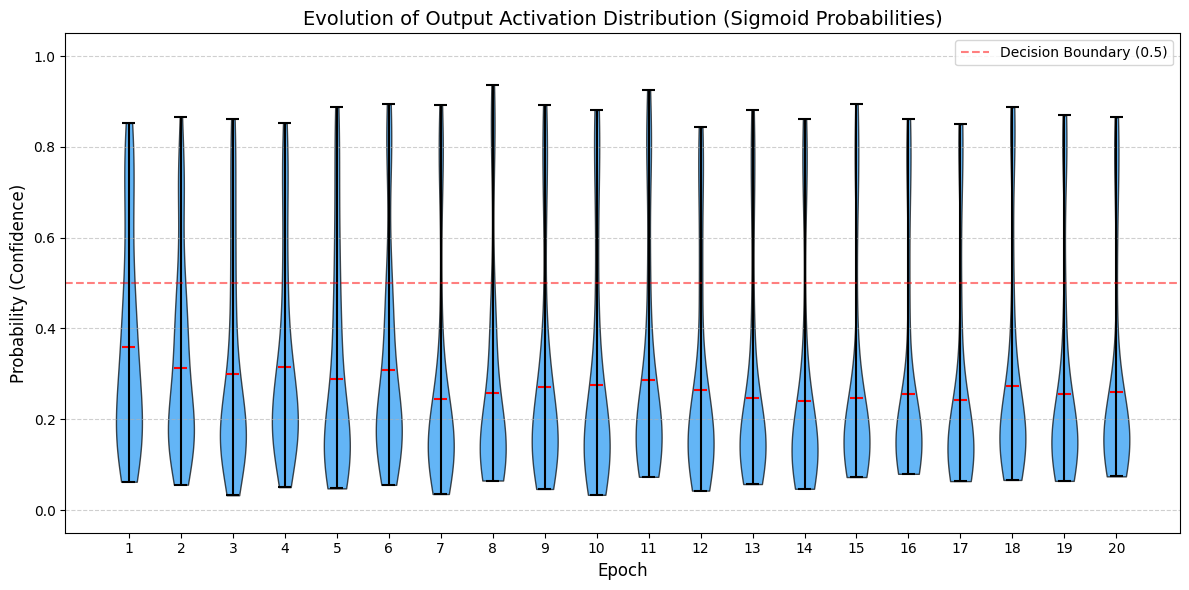

In [ ]:
# ── Plot Distributions ────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))

# Create violin plot
parts = plt.violinplot(all_probs, positions=ckpts, showmeans=True, showmedians=False)

# Customize aesthetics
for pc in parts['bodies']:
    pc.set_facecolor('#2196F3')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

parts['cbars'].set_edgecolor('black')
parts['cmaxes'].set_edgecolor('black')
parts['cmins'].set_edgecolor('black')
parts['cmeans'].set_edgecolor('red')

plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision Boundary (0.5)')

plt.title("Evolution of Output Activation Distribution (Sigmoid Probabilities)", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Probability (Confidence)", fontsize=12)
plt.xticks(ckpts)
plt.ylim(-0.05, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

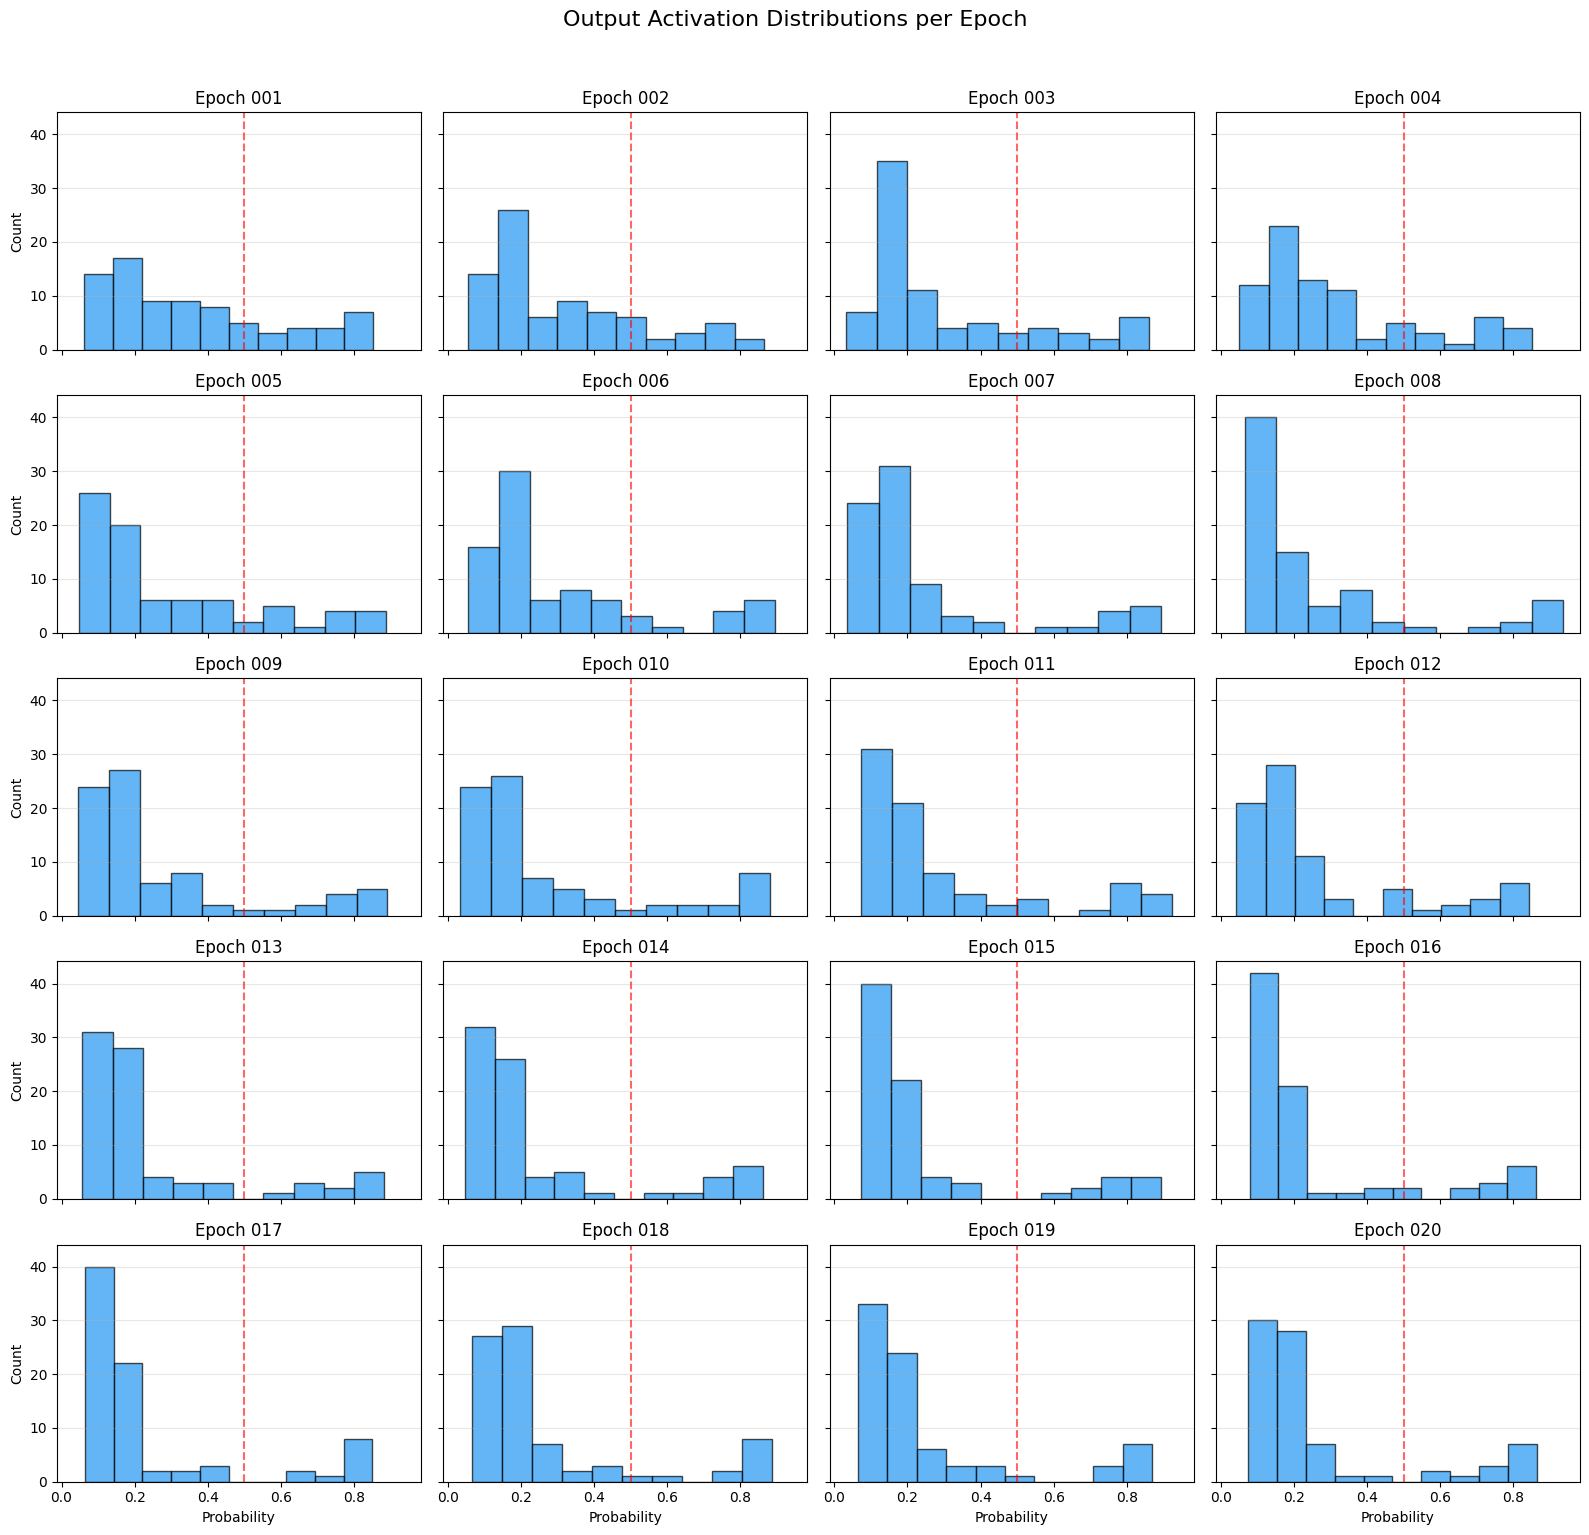

In [ ]:
# ── Plot Distributions (Histograms) ──────────────────────────────────────────
if all_probs:
    n_ckpts = len(all_probs)
    cols = 4
    rows = math.ceil(n_ckpts / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for i, (probs, epoch) in enumerate(zip(all_probs, ckpts)):
        ax = axes[i]
        ax.hist(probs, bins=10, color='#2196F3', alpha=0.7, edgecolor='black')
        ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.6)
        ax.set_title(f"Epoch {epoch:03d}")
        ax.grid(axis='y', alpha=0.3)
        
        if i >= (rows - 1) * cols:
            ax.set_xlabel("Probability")
        if i % cols == 0:
            ax.set_ylabel("Count")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.suptitle("Output Activation Distributions per Epoch", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")